# Dates — date-enrichment cascade, polity-of-citizenship age, and life expectancy through history.

In [1]:
import re
import random
from pathlib import Path

import numpy as np
import polars as pl
import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../../data/humans_clean.duckdb'
CV_PATH = '../../data/similar_databases/cross-verified-database/cross-verified-database.utf8.csv.gz'

COLORS = {
    'primary':       '#2171b5',
    'alt':           '#b5542a',
    'accent':        '#6a9e3a',
    'neutral':       '#7f7f7f',
    'text':          '#444444',
    'cascade':       '#3a8fbf',
    'life_dot':      '#9aa0a6',
    'life_line':     '#c1121f',
}

OCCUPATION_COLORS = {
    'Culture':           '#2171b5',
    'Discovery/Science': '#238b45',
    'Leadership':        '#c2440a',
    'Sports/Games':      '#7b3294',
}

mpl.rcParams.update({
    'figure.dpi':       120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'legend.fontsize':   10,
})


## Connect

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)


## Primary date flags from `individuals`  (original / description / works / cross-verified DB)

In [3]:
primary_flags = con.execute("""
    SELECT  wikidata_id,
            (birthdate IS NOT NULL OR deathdate IS NOT NULL OR floruit_date IS NOT NULL)
                AS has_original,
            (birthdate_in_description IS NOT NULL OR deathdate_in_description IS NOT NULL
             OR floruit_year_in_description IS NOT NULL OR dates_in_description IS NOT NULL)
                AS has_description,
            (works_period IS NOT NULL)
                AS has_works,
            (birthdate_from_CV IS NOT NULL OR deathdate_from_CV IS NOT NULL)
                AS has_cv
    FROM    individuals
""").pl()

print('shape:', primary_flags.shape)
primary_flags.head()


shape: (13003420, 5)


wikidata_id,has_original,has_description,has_works,has_cv
str,bool,bool,bool,bool
"""Q10000001""",true,true,false,false
"""Q1000002""",true,true,true,true
"""Q10000029""",false,false,false,false
"""Q1000005""",true,true,true,true
"""Q1000006""",true,false,true,true


## Individuals whose country of citizenship has an inception or dissolution date

In [4]:
country_dated_individuals = con.execute("""
    WITH
      country_pairs AS (
        SELECT  individuals_keys.wikidata_id,
                TRIM(country.qid) AS country_qid
        FROM    individuals_keys,
                UNNEST(string_split(individuals_keys.country_of_citizenship_ids, ';')) AS country(qid)
        WHERE   individuals_keys.country_of_citizenship_ids IS NOT NULL
      )
    SELECT DISTINCT
            country_pairs.wikidata_id
    FROM    country_pairs
    JOIN    country_of_citizenship
        ON  country_of_citizenship.wikidata_id = country_pairs.country_qid
    WHERE   country_of_citizenship.inception IS NOT NULL
       OR   country_of_citizenship.dissolved IS NOT NULL
""").pl()

print('shape:', country_dated_individuals.shape)
country_dated_individuals.head()


shape: (5565202, 1)


wikidata_id
str
"""Q108896550"""
"""Q108896670"""
"""Q108896761"""
"""Q108897098"""
"""Q108899534"""


## Individuals whose birth or death city has an inception or dissolution date

In [5]:
city_dated_individuals = con.execute("""
    WITH
      dated_cities AS (
        SELECT id FROM places
        WHERE inception_date IS NOT NULL OR dissolution_date IS NOT NULL
      ),
      birth_city_match AS (
        SELECT individuals_keys.wikidata_id
        FROM individuals_keys
        JOIN dated_cities ON dated_cities.id = individuals_keys.birthcity_id
      ),
      death_city_match AS (
        SELECT individuals_keys.wikidata_id
        FROM individuals_keys
        JOIN dated_cities ON dated_cities.id = individuals_keys.deathcity_id
      )
    SELECT DISTINCT wikidata_id FROM (
      SELECT wikidata_id FROM birth_city_match
      UNION ALL
      SELECT wikidata_id FROM death_city_match
    )
""").pl()

print('shape:', city_dated_individuals.shape)
city_dated_individuals.head()


shape: (2373128, 1)


wikidata_id
str
"""Q106643837"""
"""Q1066439"""
"""Q1066454"""
"""Q106646227"""
"""Q106646265"""


## Combined per-individual date flags

In [6]:
individual_date_flags = (
    primary_flags
    .with_columns(
        pl.col('wikidata_id').is_in(country_dated_individuals['wikidata_id']).alias('has_country_span'),
        pl.col('wikidata_id').is_in(city_dated_individuals['wikidata_id']).alias('has_city_span'),
    )
)

print('shape:', individual_date_flags.shape)
individual_date_flags.head()


/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_23056/2713529937.py:3: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns(


shape: (13003420, 7)


wikidata_id,has_original,has_description,has_works,has_cv,has_country_span,has_city_span
str,bool,bool,bool,bool,bool,bool
"""Q10000001""",true,true,false,false,true,true
"""Q1000002""",true,true,true,true,true,true
"""Q10000029""",false,false,false,false,true,false
"""Q1000005""",true,true,true,true,true,false
"""Q1000006""",true,false,true,true,true,true


## Recursive cascade  (each individual attributed to the first matching source)

In [7]:
ENRICHMENT_STEPS = [
    ('Originally (at least one date)',         'has_original'),
    ('From descriptions',                       'has_description'),
    ('From works (min/max dates)',              'has_works'),
    ('From the cross-verified database',        'has_cv'),
    ('From the country-of-citizenship span',    'has_country_span'),
    ('From the birth/death city span',          'has_city_span'),
]

total_individuals = individual_date_flags.height
already_covered = pl.Series('covered', [False] * total_individuals)
cascade_rows = []

for step_label, flag_column in ENRICHMENT_STEPS:
    flag = individual_date_flags[flag_column]
    newly_covered = flag & ~already_covered
    new_count = int(newly_covered.sum())
    already_covered = already_covered | flag
    cumulative_count = int(already_covered.sum())
    cascade_rows.append({
        'step':      step_label,
        'added':     new_count,
        'added_pct': new_count / total_individuals * 100,
        'cum_pct':   cumulative_count / total_individuals * 100,
    })

cascade = pl.DataFrame(cascade_rows)
print('total_individuals:', f'{total_individuals:,}')
print('shape:', cascade.shape)
cascade


total_individuals: 13,003,420
shape: (6, 4)


step,added,added_pct,cum_pct
str,i64,f64,f64
"""Originally (at least one date)""",7813121,60.085124,60.085124
"""From descriptions""",173209,1.332026,61.41715
"""From works (min/max dates)""",2166963,16.664562,78.081712
"""From the cross-verified databa…",3105,0.023878,78.105591
"""From the country-of-citizenshi…",854499,6.57134,84.676931
"""From the birth/death city span""",17406,0.133857,84.810788


## Paper-ready markdown table

In [8]:
def fmt_pct(p):
    return '<0.1%' if 0 < p < 0.1 else f'{p:.2f}%'

print('| Method | Unique individuals dated | Cumulative coverage |')
print('|---|---:|---:|')
for row in cascade.iter_rows(named=True):
    print(f"| {row['step']} | +{fmt_pct(row['added_pct'])} | {row['cum_pct']:.2f}% |")
final_coverage = cascade[-1, 'cum_pct']
print(f'| **Total with date/period** | **{final_coverage:.2f}%** | **{final_coverage:.2f}%** |')


| Method | Unique individuals dated | Cumulative coverage |
|---|---:|---:|
| Originally (at least one date) | +60.09% | 60.09% |
| From descriptions | +1.33% | 61.42% |
| From works (min/max dates) | +16.66% | 78.08% |
| From the cross-verified database | +<0.1% | 78.11% |
| From the country-of-citizenship span | +6.57% | 84.68% |
| From the birth/death city span | +0.13% | 84.81% |
| **Total with date/period** | **84.81%** | **84.81%** |


## Country of citizenship table  (one row per polity, with raw inception/dissolved date strings)

In [9]:
country_polities = con.execute("""
    SELECT  wikidata_id,
            name_en,
            count       AS n_individuals,
            inception,
            dissolved
    FROM    country_of_citizenship
""").pl()

print('shape:', country_polities.shape)
country_polities.head()


shape: (4572, 5)


wikidata_id,name_en,n_individuals,inception,dissolved
str,str,i64,str,str
"""Q570740""","""Duchy of Legnica""",8,"""1248-01-01T00:00:00Z""","""1675-11-21T00:00:00Z"""
"""Q25272716""","""Maore sultanate""",2,"""1500-01-01T00:00:00Z""","""1841-04-25T00:00:00Z"""
"""Q284667""","""Electorate of Mainz""",22,"""0780-01-01T00:00:00Z""","""1803-01-01T00:00:00Z"""
"""Q3845757""","""Marquisate of Bosco""",1,null,null
"""Q1062546""","""Later Jin (1616-1636)""",15,"""1616-01-01T00:00:00Z""","""1636-01-01T00:00:00Z"""


## Parse polity dates  (earliest inception, latest dissolution, lifespan)

In [10]:
ISO_YEAR_PATTERN = re.compile(r'^(-?\d{1,4})-\d{2}-\d{2}T')

def parse_year_list(cell):
    if cell is None or cell == '':
        return []
    out = []
    for token in cell.split('|'):
        match = ISO_YEAR_PATTERN.match(token.strip())
        if match:
            out.append(int(match.group(1)))
    return out

def earliest_year(cell):
    years = parse_year_list(cell)
    return min(years) if years else None

def latest_year(cell):
    years = parse_year_list(cell)
    return max(years) if years else None

country_polities = country_polities.with_columns(
    pl.col('inception').map_elements(earliest_year, return_dtype=pl.Int64).alias('inception_year'),
    pl.col('dissolved').map_elements(latest_year,   return_dtype=pl.Int64).alias('dissolved_year'),
).with_columns(
    (pl.col('dissolved_year') - pl.col('inception_year')).alias('lifespan_years')
)

print('shape:', country_polities.shape)
country_polities.select(['name_en', 'n_individuals', 'inception_year', 'dissolved_year', 'lifespan_years']).head()


shape: (4572, 8)


name_en,n_individuals,inception_year,dissolved_year,lifespan_years
str,i64,i64,i64,i64
"""Duchy of Legnica""",8,1248,1675,427
"""Maore sultanate""",2,1500,1841,341
"""Electorate of Mainz""",22,780,1803,1023
"""Marquisate of Bosco""",1,null,null,null
"""Later Jin (1616-1636)""",15,1616,1636,20


## Polity age weighted by individuals  (modern inception → today / dissolution)

In [11]:
TODAY_YEAR = 2026

country_polities = country_polities.with_columns(
    pl.col('inception').map_elements(latest_year, return_dtype=pl.Int64).alias('modern_inception_year')
).with_columns(
    pl.when(pl.col('dissolved_year').is_not_null())
      .then(pl.col('dissolved_year') - pl.col('modern_inception_year'))
      .otherwise(TODAY_YEAR - pl.col('modern_inception_year'))
      .alias('polity_age')
)

aged_polities = country_polities.filter(pl.col('polity_age').is_not_null())
ages    = aged_polities['polity_age'].to_numpy().astype(float)
weights = aged_polities['n_individuals'].to_numpy().astype(float)

print(f'aged_polities: {aged_polities.height:,}  '
      f'({100 * aged_polities.height / country_polities.height:.1f}% of all)')
print(f'individuals covered: {int(weights.sum()):,}')
aged_polities.select(['name_en', 'n_individuals', 'modern_inception_year', 'polity_age']).sort('n_individuals', descending=True).head(10)


aged_polities: 2,779  (60.8% of all)
individuals covered: 6,028,684


name_en,n_individuals,modern_inception_year,polity_age
str,i64,i64,i64
"""United States""",659823,1784,242
"""France""",387185,1804,222
"""Germany""",325196,1949,77
"""Japan""",252340,1947,79
"""United Kingdom""",233021,1927,99
"""Spain""",175862,1978,48
"""Soviet Union""",173248,1922,69
"""Italy""",151615,1946,80
"""Canada""",140125,1867,159


## Fig 1 — Cumulative share of individuals by polity age

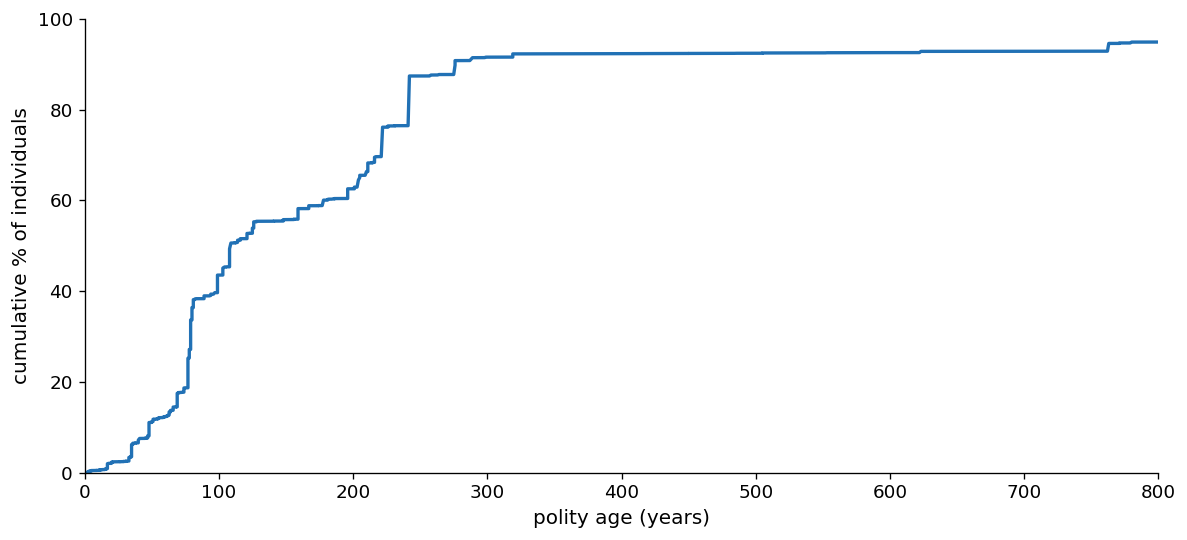

In [12]:
POLITY_AGE_X_MAX = 800

order = np.argsort(ages)
ages_sorted    = ages[order]
weights_sorted = weights[order]
cumulative_share = np.cumsum(weights_sorted) / weights_sorted.sum()

xs = np.concatenate([[0], ages_sorted, [ages_sorted.max()]])
ys = np.concatenate([[0], cumulative_share,  [1.0]])

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(xs, 100 * ys, color=COLORS['primary'], lw=2)

ax.set_xlim(0, POLITY_AGE_X_MAX)
ax.set_ylim(0, 100)
ax.set_xlabel('polity age (years)')
ax.set_ylabel('cumulative % of individuals')
plt.tight_layout()
plt.show()


## Birth + death dates  (year-precision, used for life expectancy)

In [13]:
birth_death_pairs = con.execute("""
    SELECT  wikidata_id, birthdate, deathdate
    FROM    individuals
    WHERE   birthdate IS NOT NULL
      AND   deathdate IS NOT NULL
      AND   birthdate NOT LIKE '\\_:%' ESCAPE '\\'
      AND   deathdate NOT LIKE '\\_:%' ESCAPE '\\'
      AND   birthdate_precision >= 9
      AND   deathdate_precision >= 9
""").pl()

print('shape:', birth_death_pairs.shape)
birth_death_pairs.head()


shape: (3117213, 3)


wikidata_id,birthdate,deathdate
str,str,str
"""Q10000001""","""1937-04-11""","""2016-03-17"""
"""Q1000002""","""1932-12-04""","""1990-04-12"""
"""Q1000005""","""1860-02-21""","""1927-11-03"""
"""Q100000857""","""1617-01-01""","""1692-01-01"""
"""Q100000889""","""1803-01-01""","""1897-01-01"""


## Life expectancy in years  (Polars: parse fractional year, filter [0, 130])

In [14]:
LIFE_EXPECTANCY_MIN = 0
LIFE_EXPECTANCY_MAX = 130
DAYS_PER_MONTH      = 30
DAYS_PER_YEAR       = 365.0

def parse_fractional_year(date_column):
    column = pl.col(date_column)
    is_bce = column.str.starts_with('-')
    year   = column.str.extract(r'^-?(\d{1,5})', 1).cast(pl.Int64, strict=False)
    month  = column.str.extract(r'^-?\d{1,5}-(\d{1,2})', 1).cast(pl.Int64, strict=False).fill_null(1)
    day    = column.str.extract(r'^-?\d{1,5}-\d{1,2}-(\d{1,2})', 1).cast(pl.Int64, strict=False).fill_null(1)
    signed = pl.when(is_bce).then(-year).otherwise(year)
    return (signed + (DAYS_PER_MONTH * (month - 1) + (day - 1)) / DAYS_PER_YEAR).alias(f'{date_column}_yr')

life_expectancy = (
    birth_death_pairs
    .with_columns([parse_fractional_year('birthdate'), parse_fractional_year('deathdate')])
    .with_columns(
        (pl.col('deathdate_yr') - pl.col('birthdate_yr')).alias('life_expectancy_years'),
        pl.col('birthdate_yr').floor().cast(pl.Int64).alias('birth_year'),
    )
    .drop_nulls(['life_expectancy_years', 'birth_year'])
    .filter(
        (pl.col('life_expectancy_years') >= LIFE_EXPECTANCY_MIN)
        & (pl.col('life_expectancy_years') <= LIFE_EXPECTANCY_MAX)
    )
)

print('shape:', life_expectancy.shape)
life_expectancy.select(['birth_year', 'life_expectancy_years']).head()


shape: (3116512, 7)


birth_year,life_expectancy_years
i64,f64
1937,78.934247
1932,57.364384
1860,67.690411
1617,75.0
1803,94.0


## Median life expectancy per 50-year birth bin  (n ≥ 50, birth ≤ 1900)

In [15]:
BIN_WIDTH       = 50
MIN_BIN_N       = 50
MAX_BIRTH_YEAR  = 1900

life_expectancy_by_bin = (
    life_expectancy
    .filter(pl.col('birth_year') <= MAX_BIRTH_YEAR)
    .with_columns(((pl.col('birth_year') // BIN_WIDTH) * BIN_WIDTH).cast(pl.Int64).alias('birth_bin'))
    .group_by('birth_bin')
    .agg(
        pl.col('life_expectancy_years').median().alias('median_life_expectancy'),
        pl.col('life_expectancy_years').mean().alias('mean_life_expectancy'),
        pl.len().alias('n'),
    )
    .filter(pl.col('n') >= MIN_BIN_N)
    .sort('birth_bin')
)

print('shape:', life_expectancy_by_bin.shape)
life_expectancy_by_bin.head()


shape: (49, 4)


birth_bin,median_life_expectancy,mean_life_expectancy,n
i64,f64,f64,u32
-500,66.0,64.449129,59
-450,57.0,60.019569,63
-400,60.0,60.593073,106
-350,60.0,57.769806,96
-300,56.0,55.836323,93


## Fig 2 — Life expectancy through history

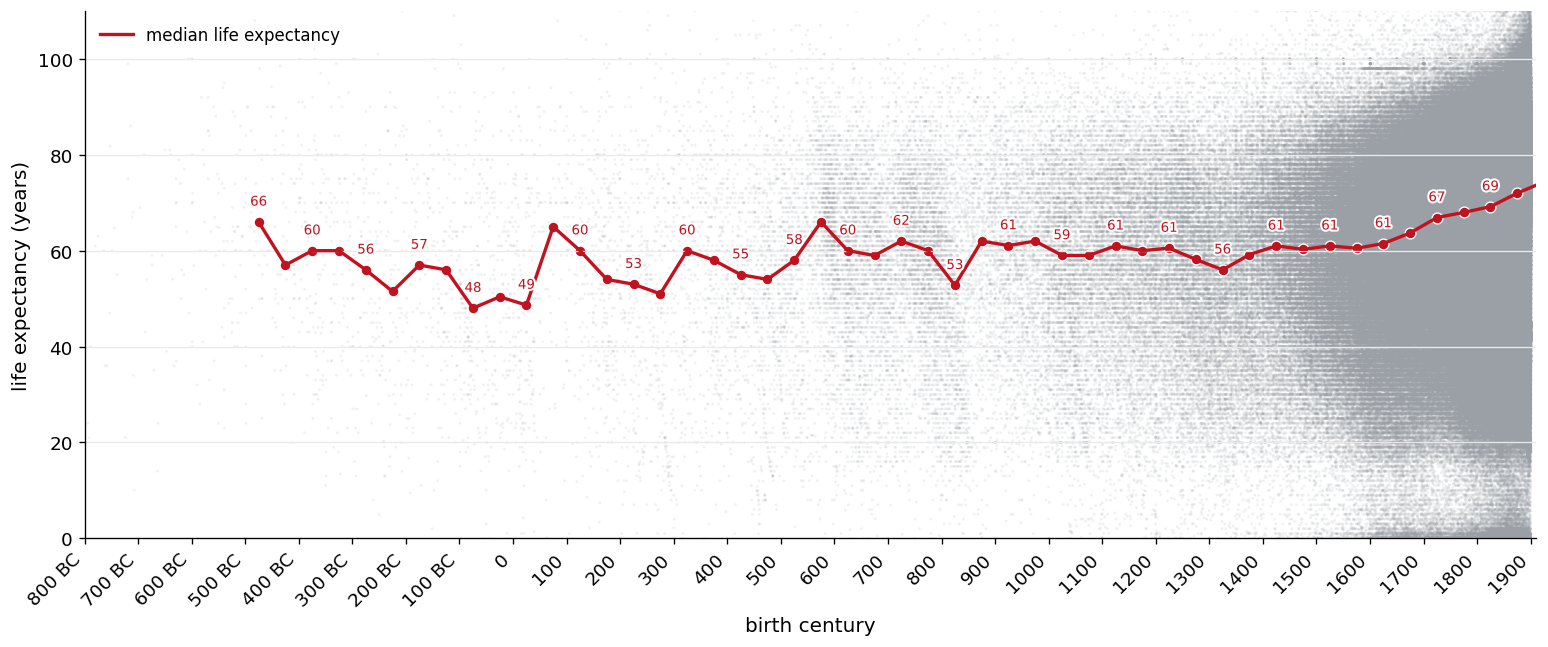

In [16]:
X_MIN, X_MAX = -800, 1910

individuals_to_plot = life_expectancy.filter(
    (pl.col('birth_year') >= X_MIN) & (pl.col('birth_year') <= MAX_BIRTH_YEAR)
)
individual_x = individuals_to_plot['birth_year'].to_numpy()
individual_y = individuals_to_plot['life_expectancy_years'].to_numpy()

bins_to_plot = life_expectancy_by_bin.filter(pl.col('birth_bin') >= X_MIN).sort('birth_bin')
bin_x = bins_to_plot['birth_bin'].to_numpy() + BIN_WIDTH / 2
bin_median = bins_to_plot['median_life_expectancy'].to_numpy()

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.scatter(individual_x, individual_y, s=3.0, color=COLORS['life_dot'],
           alpha=0.14, edgecolor='none', rasterized=True)
ax.plot(bin_x, bin_median, color=COLORS['life_line'], lw=2.0,
        label='median life expectancy')
ax.scatter(bin_x, bin_median, s=42, color=COLORS['life_line'],
           edgecolor='white', lw=0.8)
for i, (x, y) in enumerate(zip(bin_x, bin_median)):
    if i % 2 == 0:
        ax.annotate(
            f'{y:.0f}', (x, y),
            textcoords='offset points', xytext=(0, 8),
            ha='center', va='bottom',
            fontsize=8, color=COLORS['life_line'],
            path_effects=[patheffects.withStroke(linewidth=2.5, foreground='white')],
        )

century_ticks = np.arange(-800, 1901, 100)
century_labels = [f'{abs(c)} BC' if c < 0 else ('0' if c == 0 else f'{c}') for c in century_ticks]
ax.set_xticks(century_ticks)
ax.set_xticklabels(century_labels, rotation=45, ha='right')
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(0, 110)
ax.set_xlabel('birth century')
ax.set_ylabel('life expectancy (years)')
ax.grid(axis='y', color='#eaeaea', lw=0.8)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()


## Cross-verified occupations  (top-level category per individual)

In [17]:
cv_occupations = (
    pl.read_csv(
        CV_PATH,
        columns=['wikidata_code', 'level1_main_occ'],
        schema_overrides={'wikidata_code': pl.Utf8, 'level1_main_occ': pl.Utf8},
    )
    .drop_nulls(['wikidata_code', 'level1_main_occ'])
    .rename({'wikidata_code': 'wikidata_id'})
)

print('shape:', cv_occupations.shape)
cv_occupations.head()


shape: (2291817, 2)


wikidata_id,level1_main_occ
str,str
"""Q1000002""","""Culture"""
"""Q1000005""","""Culture"""
"""Q1000006""","""Culture"""
"""Q1000015""","""Culture"""
"""Q1000023""","""Leadership"""


## Life expectancy joined to CV occupations  (per 50-year birth bin)

In [18]:
SHOW_OCCUPATIONS = ['Culture', 'Discovery/Science', 'Leadership', 'Sports/Games']

life_expectancy_with_occupation = (
    life_expectancy
    .join(cv_occupations, on='wikidata_id', how='inner')
    .filter(pl.col('birth_year') <= MAX_BIRTH_YEAR)
    .filter(pl.col('level1_main_occ').is_in(SHOW_OCCUPATIONS))
)

life_expectancy_by_bin_occupation = (
    life_expectancy_with_occupation
    .with_columns(((pl.col('birth_year') // BIN_WIDTH) * BIN_WIDTH).cast(pl.Int64).alias('birth_bin'))
    .group_by('level1_main_occ', 'birth_bin')
    .agg(
        pl.col('life_expectancy_years').median().alias('median_life_expectancy'),
        pl.len().alias('n'),
    )
    .filter(pl.col('n') >= MIN_BIN_N)
    .sort('level1_main_occ', 'birth_bin')
)

print('individuals shape:', life_expectancy_with_occupation.shape)
print('per-bin shape:    ', life_expectancy_by_bin_occupation.shape)
life_expectancy_by_bin_occupation.head()


individuals shape: (557608, 8)
per-bin shape:     (94, 4)


level1_main_occ,birth_bin,median_life_expectancy,n
str,i64,f64,u32
"""Culture""",700,67.0,52
"""Culture""",750,62.731507,55
"""Culture""",900,62.152055,64
"""Culture""",950,63.0,65
"""Culture""",1000,64.621918,69


## Fig 3 — Life expectancy through history, by cross-verified occupation

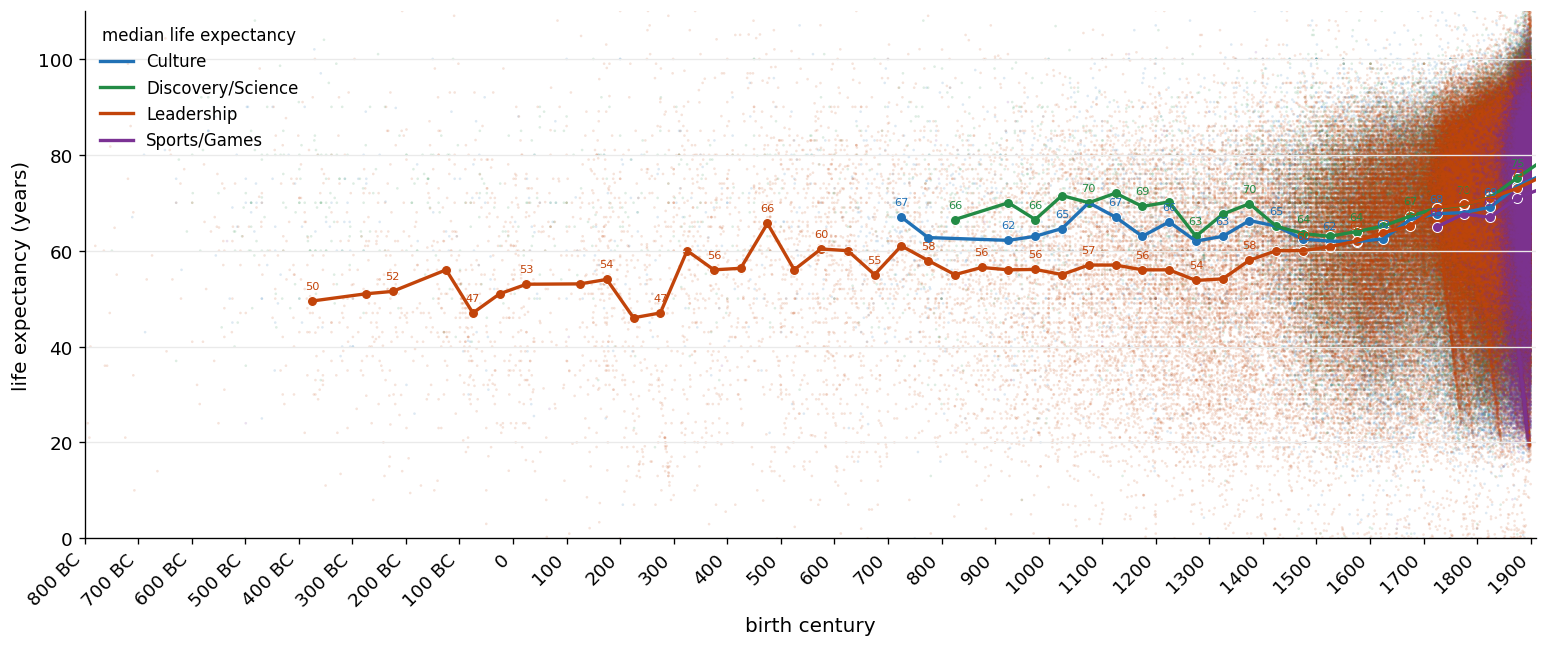

In [19]:
fig, ax = plt.subplots(figsize=(13, 5.5))

for occupation in SHOW_OCCUPATIONS:
    individuals_in_cat = life_expectancy_with_occupation.filter(
        (pl.col('level1_main_occ') == occupation) & (pl.col('birth_year') >= X_MIN)
    )
    if individuals_in_cat.height == 0:
        continue
    color = OCCUPATION_COLORS[occupation]
    ax.scatter(
        individuals_in_cat['birth_year'].to_numpy(),
        individuals_in_cat['life_expectancy_years'].to_numpy(),
        s=2.5, color=color, alpha=0.15, edgecolor='none', rasterized=True,
    )

for occupation in SHOW_OCCUPATIONS:
    bins_in_cat = (
        life_expectancy_by_bin_occupation
        .filter((pl.col('level1_main_occ') == occupation) & (pl.col('birth_bin') >= X_MIN))
        .sort('birth_bin')
    )
    if bins_in_cat.height == 0:
        continue
    color = OCCUPATION_COLORS[occupation]
    bin_x = bins_in_cat['birth_bin'].to_numpy() + BIN_WIDTH / 2
    bin_med = bins_in_cat['median_life_expectancy'].to_numpy()
    ax.plot(bin_x, bin_med, color=color, lw=2.0, label=occupation)
    ax.scatter(bin_x, bin_med, s=36, color=color, edgecolor='white', lw=0.6)
    for i, (x, y) in enumerate(zip(bin_x, bin_med)):
        if i % 2 == 0:
            ax.annotate(f'{y:.0f}', (x, y),
                        xytext=(0, 6), textcoords='offset points',
                        ha='center', va='bottom', fontsize=6.8, color=color)

ax.set_xticks(century_ticks)
ax.set_xticklabels(century_labels, rotation=45, ha='right')
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(0, 110)
ax.set_xlabel('birth century')
ax.set_ylabel('life expectancy (years)')
ax.grid(axis='y', color='#eaeaea', lw=0.8)
ax.legend(frameon=False, loc='upper left', title='median life expectancy')
plt.tight_layout()
plt.show()


## Close

In [20]:
con.close()
